Varshini Narayanan
This code scrapes market volatility data from FRED. AI used to help get the specific layout for the graph.

In [2]:
import requests
import pandas as pd

FRED_API_KEY = "623866294175c03af09c98678067f3ae"

url = "https://api.stlouisfed.org/fred/series/observations"

params = {
    "series_id": "SP500",
    "api_key": FRED_API_KEY,
    "file_type": "json",
    "observation_start": "2010-01-01"
}

response = requests.get(url, params=params)
data = response.json()

sp500 = pd.DataFrame(data["observations"])
sp500["date"] = pd.to_datetime(sp500["date"])
sp500["price"] = pd.to_numeric(sp500["value"], errors="coerce")

sp500 = sp500[["date", "price"]].dropna().reset_index(drop=True)


In [ ]:
# daily returns
sp500["ret"] = sp500["price"].pct_change()

# Rolling realized volatility; 21 days
sp500["realized_vol"] = sp500["ret"].rolling(21).std()

sp500 = sp500.dropna().reset_index(drop=True)


In [ ]:
#stress days defined at top 10% of market volatility
threshold = sp500["realized_vol"].quantile(0.90)
sp500["stress"] = (sp500["realized_vol"] >= threshold).astype(int)
stress_days = sp500[sp500["stress"] == 1]


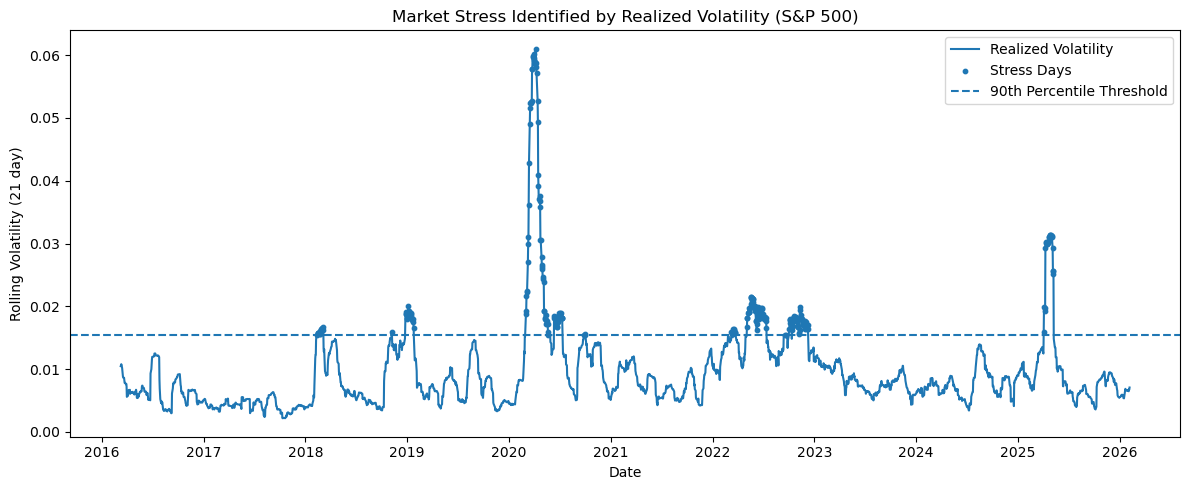

In [9]:
#visulaization for stress days over time
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(sp500["date"], sp500["realized_vol"], label="Realized Volatility")

# mark stress days
plt.scatter(
    sp500.loc[sp500["stress"] == 1, "date"],
    sp500.loc[sp500["stress"] == 1, "realized_vol"],
    label="Stress Days",
    s=10
)

plt.axhline(
    sp500["realized_vol"].quantile(0.90),
    linestyle="--",
    label="90th Percentile Threshold"
)

plt.title("Market Stress Identified by Realized Volatility (S&P 500)")
plt.xlabel("Date")
plt.ylabel("Rolling Volatility (21 day)")
plt.legend()
plt.tight_layout()
plt.show()


In [6]:
stress_days = (
    sp500.loc[sp500["stress"] == 1, ["date", "realized_vol"]]
    .rename(columns={"realized_vol": "market_realized_vol"})
    .reset_index(drop=True)
)


In [ ]:
stress_days["date"] = pd.to_datetime(stress_days["date"])

In [ ]:
#save as csv
stress_days.to_csv("stress_days.csv", index=False)